# FIE463 Term Paper 2

## Expectations about macroeconomic and financial variables

### Candidates: 66, 56, 54

### AI Disclaimer
All code and text in this file is our own. We have used AI to assess our own code, and for discussing possible ways to solve each task. AI has only acted as a support and all text, code and output are our own.

### Note on runtime
The full execution of this notebook (particularly the cross-validation steps in Parts 5 and 6) may take a few minutes to complete. This is due to the use of model tuning procedures (e.g., cross-validation and grid search) to ensure robust and comparable results across specifications.

In [1]:
# Import the main libraries used throughout the notebook
import glob
import os
import warnings

# Data structures, vectorization and graphical representation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Scikit-Learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Suppress warnings in the notebook output
warnings.filterwarnings('ignore') # Removes warnings in output

## Part 1 - Data preprocessing (SCE)

In this part, we preprocess the Survey of Consumer Expectations (SCE) data.

We first import and merge the yearly SCE extract files into one DataFrame. We then sort the data by individual and date, which makes it possible to carry forward selected variables that are only asked in the initial interview. After that, we drop all observations from 2025, remove observations with missing values in the variables used later in the analysis, and trim outliers in the four main expectations variables.

Finally, we create three binary optimism indicators:
- `optimist_unrate`
- `optimist_stocks`
- `optimist_house_price`

These variables are used later in the classification part of the term paper.

### 1.1 Import and merge the data

In [2]:
# Path to the data folder
DATA_DIR = './data'

# Create a file pattern that matches all yearly SCE extract files
file_pattern = os.path.join(DATA_DIR, "sce_extract_*.csv")
file_list = glob.glob(file_pattern)

# Load all yearly SCE files and combine them into one DataFrame
df_sce = pd.concat([pd.read_csv(f) for f in file_list], ignore_index=True)

# Print a short summary of the merged raw data
print(f"Successfully merged {len(file_list)} files.")
print(f"Total initial rows: {len(df_sce)}")
print(f"Dataset columns:\n {df_sce.columns.tolist()}")

Successfully merged 13 files.
Total initial rows: 180268
Dataset columns:
 ['userid', 'wid', 'tenure', 'weight', 'date', 'financial_past_12m', 'financial_12m', 'prob_move_house', 'prob_unrate_up', 'prob_irate_up', 'prob_stocks_up', 'infl_1y', 'infl_1y_bin_mean', 'infl_1y_bin_var', 'infl_1y_bin_median', 'infl_1y_bin_iqr', 'infl_1y_bin_prob_defl', 'infl_3y', 'infl_3y_bin_mean', 'infl_3y_bin_var', 'infl_3y_bin_median', 'infl_3y_bin_iqr', 'infl_3y_bin_prob_defl', 'infl_5y', 'working', 'num_jobs', 'self_employed', 'prob_lose_job', 'prob_leave_job', 'looking_for_job', 'prob_accept_job_12m', 'prob_accept_job_3m', 'jobless_length', 'prob_search_job_12m', 'prob_search_job_3m', 'earnings_change', 'hh_inc_change', 'hh_spending_change', 'taxes_change', 'credit_cond_past_12m', 'credit_cond_12m', 'prob_miss_paym_3m', 'house_price_change', 'house_price_change_3y', 'govt_debt_change', 'num_lit_q1', 'num_lit_q1_correct', 'num_lit_q2', 'num_lit_q2_correct', 'num_lit_q3', 'num_lit_q3_correct', 'num_lit_q

### 1.2 Forward-fill variables asked only in the initial wave

In [3]:
# Convert the date column to datetime format
df_sce['date'] = pd.to_datetime(df_sce['date']) 

# Sort the data by individual and survey date
df_sce = df_sce.sort_values(by=['userid', 'date'])

# Variables that are only asked in the initial interview
initial_wave_vars = ['owner', 'educ', 'female', 'num_lit_q1_correct', 'num_lit_q2_correct', 'num_lit_q3_correct']

# Carry these variables forward within each individual over time
for col in initial_wave_vars:
    if col in df_sce.columns:
        df_sce[col] = df_sce.groupby('userid')[col].ffill()

# Confirm which variables were forward-filled
print(f"Successfully forward-filled the following initial-wave variables:\n{initial_wave_vars}")

Successfully forward-filled the following initial-wave variables:
['owner', 'educ', 'female', 'num_lit_q1_correct', 'num_lit_q2_correct', 'num_lit_q3_correct']


### 1.3 Drop Year 2025 Survey Waves
As specified in the assignment, we remove all observations from 2025 so that the final sample ends in 2024.

In [4]:
# Storing total rows before dropping 2025 observations
rows_before_drop2025 = len(df_sce)

# Filtering out 2025 using pandas boolean indexing on the datetime `.dt.year`
df_sce = df_sce[df_sce['date'].dt.year < 2025]

# Using a standard pandas copy to prevent warnings later
df_sce = df_sce.copy()

print(f"Rows before dropping 2025: {rows_before_drop2025}")
print(f"Number of observations dropped (2025): {rows_before_drop2025 - len(df_sce)}")
print(f"Total remaining rows: {len(df_sce)}")

Rows before dropping 2025: 180268
Number of observations dropped (2025): 4167
Total remaining rows: 176101


### 1.4 Clean NAs 
We define the variables used later in the analysis and drop observations with missing values in this core subset.

In [5]:
# Store the number of rows before dropping missing values
rows_before_na_drop = len(df_sce)

# Define the continuous expectation variables
expectation_vars = ['infl_1y', 'house_price_change', 'prob_unrate_up', 'prob_stocks_up']

# Define identifying variables
id_vars = ['userid', 'wid', 'date']

# Create the core set of variables used in the analysis
core_columns = id_vars + expectation_vars + initial_wave_vars

# Keep only variables that actually exist in the dataset
available_cols_to_check = [col for col in core_columns if col in df_sce.columns]

# Drop rows with missing values in the selected variables
df_sce = df_sce.dropna(subset=available_cols_to_check).copy()

# Keep only the columns used in the analysis
df_sce = df_sce[available_cols_to_check]

print(f"Rows before dropping NaNs: {rows_before_na_drop}")
print(f"Number of observations dropped (NaNs): {rows_before_na_drop - len(df_sce)}")
print(f"Total remaining rows: {len(df_sce)}")

Rows before dropping NaNs: 176101
Number of observations dropped (NaNs): 3268
Total remaining rows: 172833


### 1.5 Handle Outliers
To reduce the influence of extreme values, we trim the four main expectation variables at the 1st and 99th percentiles.

In [6]:
# Store the number of rows before trimming outliers
rows_before_outliers_drop = len(df_sce)

# Trim outliers variable by variable using the 1st and 99th percentiles
for col in expectation_vars:
    p1 = df_sce[col].quantile(0.01)
    p99 = df_sce[col].quantile(0.99)
    df_sce = df_sce[(df_sce[col] > p1) & (df_sce[col] < p99)]

print(f"Rows before handling outliers: {rows_before_outliers_drop}")
print(f"Number of outlier observations dropped: {rows_before_outliers_drop - len(df_sce)}")
print(f"Total remaining rows: {len(df_sce)}")

Rows before handling outliers: 172833
Number of outlier observations dropped: 17740
Total remaining rows: 155093


The cleaning steps reduce the size of the raw SCE sample, but they also make the remaining data more suitable for analysis. Dropping observations from 2025 ensures that the sample ends in 2024, which is important because the later prediction tasks use 2024 as the test period. Removing missing values ensures that the models are estimated on complete observations, while trimming extreme values reduces the influence of outliers in the main expectation variables.

### 1.6 & 1.7 Feature Engineering (Binary Indicators) & Final Report
We convert the continuous expectation variables into binary indicators that can be used as targets in the classification analysis in Part 6.

A respondent is classified as optimistic about unemployment if the probability assigned to unemployment increasing is below 50 percent. A respondent is classified as optimistic about stocks if the probability assigned to stock prices increasing is above 50 percent. A respondent is classified as optimistic about house prices if expected house price growth is positive.

In [7]:
# Create binary optimism indicators
df_sce['optimist_unrate'] = np.where(df_sce['prob_unrate_up'] < 50, 1, 0)
df_sce['optimist_stocks'] = np.where(df_sce['prob_stocks_up'] > 50, 1, 0)
df_sce['optimist_house_price'] = np.where(df_sce['house_price_change'] > 0, 1, 0)

# Print summary information for the cleaned SCE dataset
print("--- Final Cleaned SCE Dataset ---")
print(f"Total Unique Individuals: {df_sce['userid'].nunique()}")
print(f"Total Observations: {len(df_sce)}")
print(f"Number of Survey Waves: {df_sce['date'].nunique()}")
print(f"Starting Date: {df_sce['date'].min().strftime('%Y-%m-%d')}")
print(f"Ending Date: {df_sce['date'].max().strftime('%Y-%m-%d')}")

--- Final Cleaned SCE Dataset ---
Total Unique Individuals: 22021
Total Observations: 155093
Number of Survey Waves: 4106
Starting Date: 2013-06-01
Ending Date: 2024-12-31


## Part 2 - Macroeconomic & Financial Data
In this part, we combine the cleaned SCE data with macroeconomic and financial variables.

The variables are stored in the `data` folder and loaded from there. Daily and weekly series are resampled to monthly frequency using the last observation in each month, while quarterly variables are kept at quarterly frequency. We then create lagged changes for the macroeconomic and financial variables.

To avoid look-ahead bias, we only merge information that would have been available at the survey date.

In [8]:
# Load and process the macroeconomic and financial time series

# Map each file to its original column name and standardized variable name
# The data files have already been saved in the data folder
macro_files = {
    'CPIAUCSL.csv': ('CPIAUCSL', 'cpi'),
    'UNRATE.csv': ('UNRATE', 'unrate'),
    'GDPC1.csv': ('GDPC1', 'gdp'),
    'MORTGAGE30US.csv': ('MORTGAGE30US', 'mortgage'),
    'FEDFUNDS.csv': ('FEDFUNDS', 'fedfunds'),
    'USSTHPI.csv': ('USSTHPI', 'house_idx'),
    'GSPC.csv': ('Close', 'sp500'),
    'DTWEXBGS.csv': ('DTWEXBGS', 'dollar'),
    'CL_F.csv': ('Close', 'oil')
}

In [9]:
df_macro_list = []

# Loop over all macro and financial files
for file, (val_col, new_name) in macro_files.items():
    filepath = os.path.join(DATA_DIR, file)
    if os.path.exists(filepath):
        df_temp = pd.read_csv(filepath)
        
        # Keep only the date column and the relevant data column
        df_temp = df_temp[['Date', val_col]].rename(columns={'Date': 'date', val_col: new_name})
        
        # Convert the date column and data column to the correct format
        df_temp['date'] = pd.to_datetime(df_temp['date'])
        df_temp[new_name] = pd.to_numeric(df_temp[new_name], errors='coerce')
        
        # Sort by date and remove missing values
        df_temp = df_temp.sort_values('date').dropna()
        
        # Resample to month-end using the last observation in each month
        df_temp = df_temp.set_index('date').resample('ME').last()
        
        df_macro_list.append(df_temp)

# Combine all macro series into one DataFrame
df_macro = pd.concat(df_macro_list, axis=1)

# Forward-fill gaps caused by different publication schedules
df_macro = df_macro.ffill()

# Reset the index so date becomes a column again
df_macro = df_macro.reset_index()

print("Resampled Macro Headers:")
print(df_macro.columns.tolist())

Resampled Macro Headers:
['date', 'cpi', 'unrate', 'gdp', 'mortgage', 'fedfunds', 'house_idx', 'sp500', 'dollar', 'oil']


### 2.1 Calculate Trailing Dynamics & Merge
Households may respond not only to current macroeconomic conditions, but also to recent changes in those conditions. We therefore construct 1-month and 12-month changes for all macroeconomic variables and then merge them into the SCE data.

In [10]:
# Calculate 1-month and 12-month changes
macro_vars = [col for col in df_macro.columns if col != 'date']

# Create trailing differences and percentage changes
for col in macro_vars:
    # 1-month momentum
    df_macro[f"{col}_diff1"] = df_macro[col].diff(1)
    df_macro[f"{col}_pct1"] = df_macro[col].pct_change(1)
    
    # 12-month momentum
    df_macro[f"{col}_diff12"] = df_macro[col].diff(12)
    df_macro[f"{col}_pct12"] = df_macro[col].pct_change(12)

In [11]:
# Sort both datasets by date before merge_asof
df_sce = df_sce.sort_values('date')
df_macro = df_macro.sort_values('date')

initial_size = len(df_sce)

# Merge backward in time to avoid look-ahead bias
df_final = pd.merge_asof(
    df_sce, 
    df_macro, 
    on='date', 
    direction='backward'
)

# Drop the initial burn-in period where 12-month changes cannot yet be computed
df_final = df_final.dropna(subset=[f"{macro_vars[0]}_diff12"])

print(f"SCE shape before merge: {initial_size}")
print(f"Rows dropped due to 'burn-in' trailing macro calculation: {initial_size - len(df_final)}")
print(f"Final merged dataset size ready for modeling: {len(df_final)}")

SCE shape before merge: 155093
Rows dropped due to 'burn-in' trailing macro calculation: 0
Final merged dataset size ready for modeling: 155093


### 2.2 Economic Motivation for Feature Engineering Format Restrictions
We structure the macroeconomic regressors in three different ways: levels, absolute changes, and relative changes.

**1. Raw Levels**  
Raw levels describe the general macroeconomic environment at the time of the survey. For example, expectations about unemployment may depend on whether the unemployment rate is currently low or high.

**2. Absolute Differences (1-month and 12-month)**  
Absolute differences are most appropriate for variables that are already measured as rates, such as the unemployment rate, mortgage rate, and federal funds rate. For these variables, a change from 1 percent to 2 percent is naturally interpreted as a 1 percentage point increase.

**3. Relative Percentage Changes (1-month and 12-month)**  
Relative percentage changes are more appropriate for indices and price variables such as the S&P 500, GDP, oil prices, and the dollar index. For these variables, growth rates are easier to interpret than raw levels and better capture recent economic momentum.

This feature construction is useful because households are likely to respond both to the current level of macroeconomic conditions and to recent changes in those conditions.

After constructing the macroeconomic and financial variables, we merge them into the cleaned SCE data. This gives us one combined dataset that contains both household-level survey variables and aggregate economic variables, which will be used in the exploratory analysis and prediction tasks that follow.

## Part 3 - Exploratory Data Analysis (SCE)
In this part, we examine the main expectation variables in the SCE data.

We first plot histograms for the four continuous expectation variables in order to study their distributions. We then plot the average values of these variables over time. Finally, we plot the fraction of optimistic respondents over time for the three binary optimism indicators created in Part 1.

### 3.1 Histograms of Expectation Responses
We begin by plotting histograms for the four continuous expectation variables. These figures show how responses are distributed across individuals and help us detect skewness, concentration around focal values, and heterogeneity in beliefs.

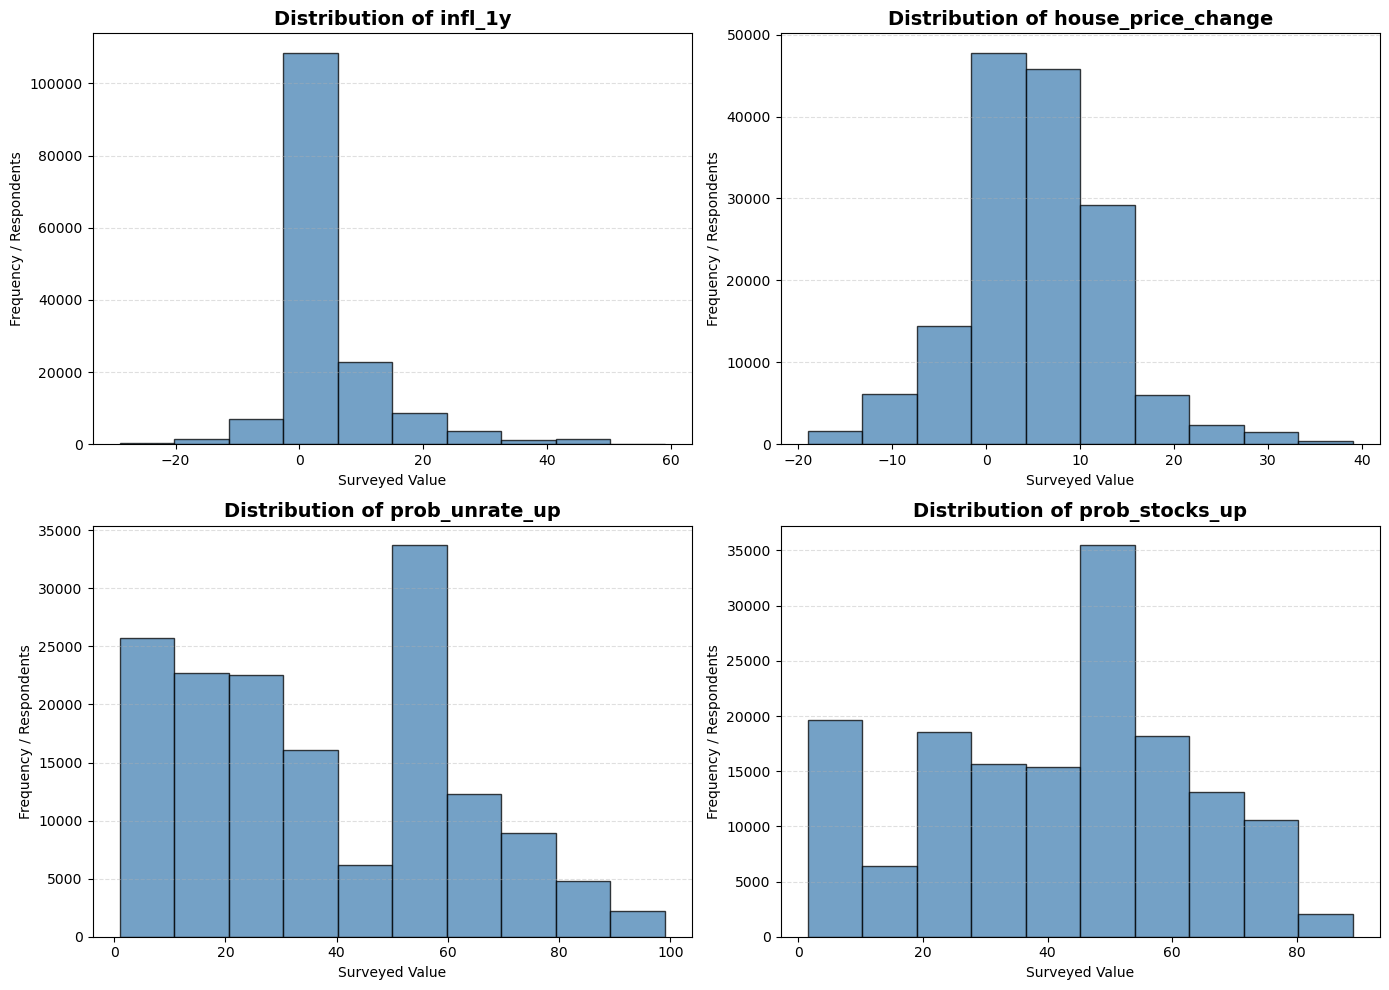

In [12]:
# Plot histograms for the four continuous expectation variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(expectation_vars):
    axes[i].hist(df_sce[col].dropna(), bins=10, color='steelblue', edgecolor='black', alpha=0.75)
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Frequency / Respondents')
    axes[i].set_xlabel('Surveyed Value')
    axes[i].grid(axis='y', alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()

The histograms show how the expectation variables are distributed across respondents. The probability variables are bounded between 0 and 100, while inflation expectations and expected house price changes have a wider continuous range. The figures suggest substantial heterogeneity in household expectations.

### 3.2 Time Series of Averages & Optimist Fractions
We aggregate the panel dataset into singular monthly timestamps by using pandas `.groupby('date').mean()`. This is to study how average expectations and the fraction of optimistic respondents evolve over time.

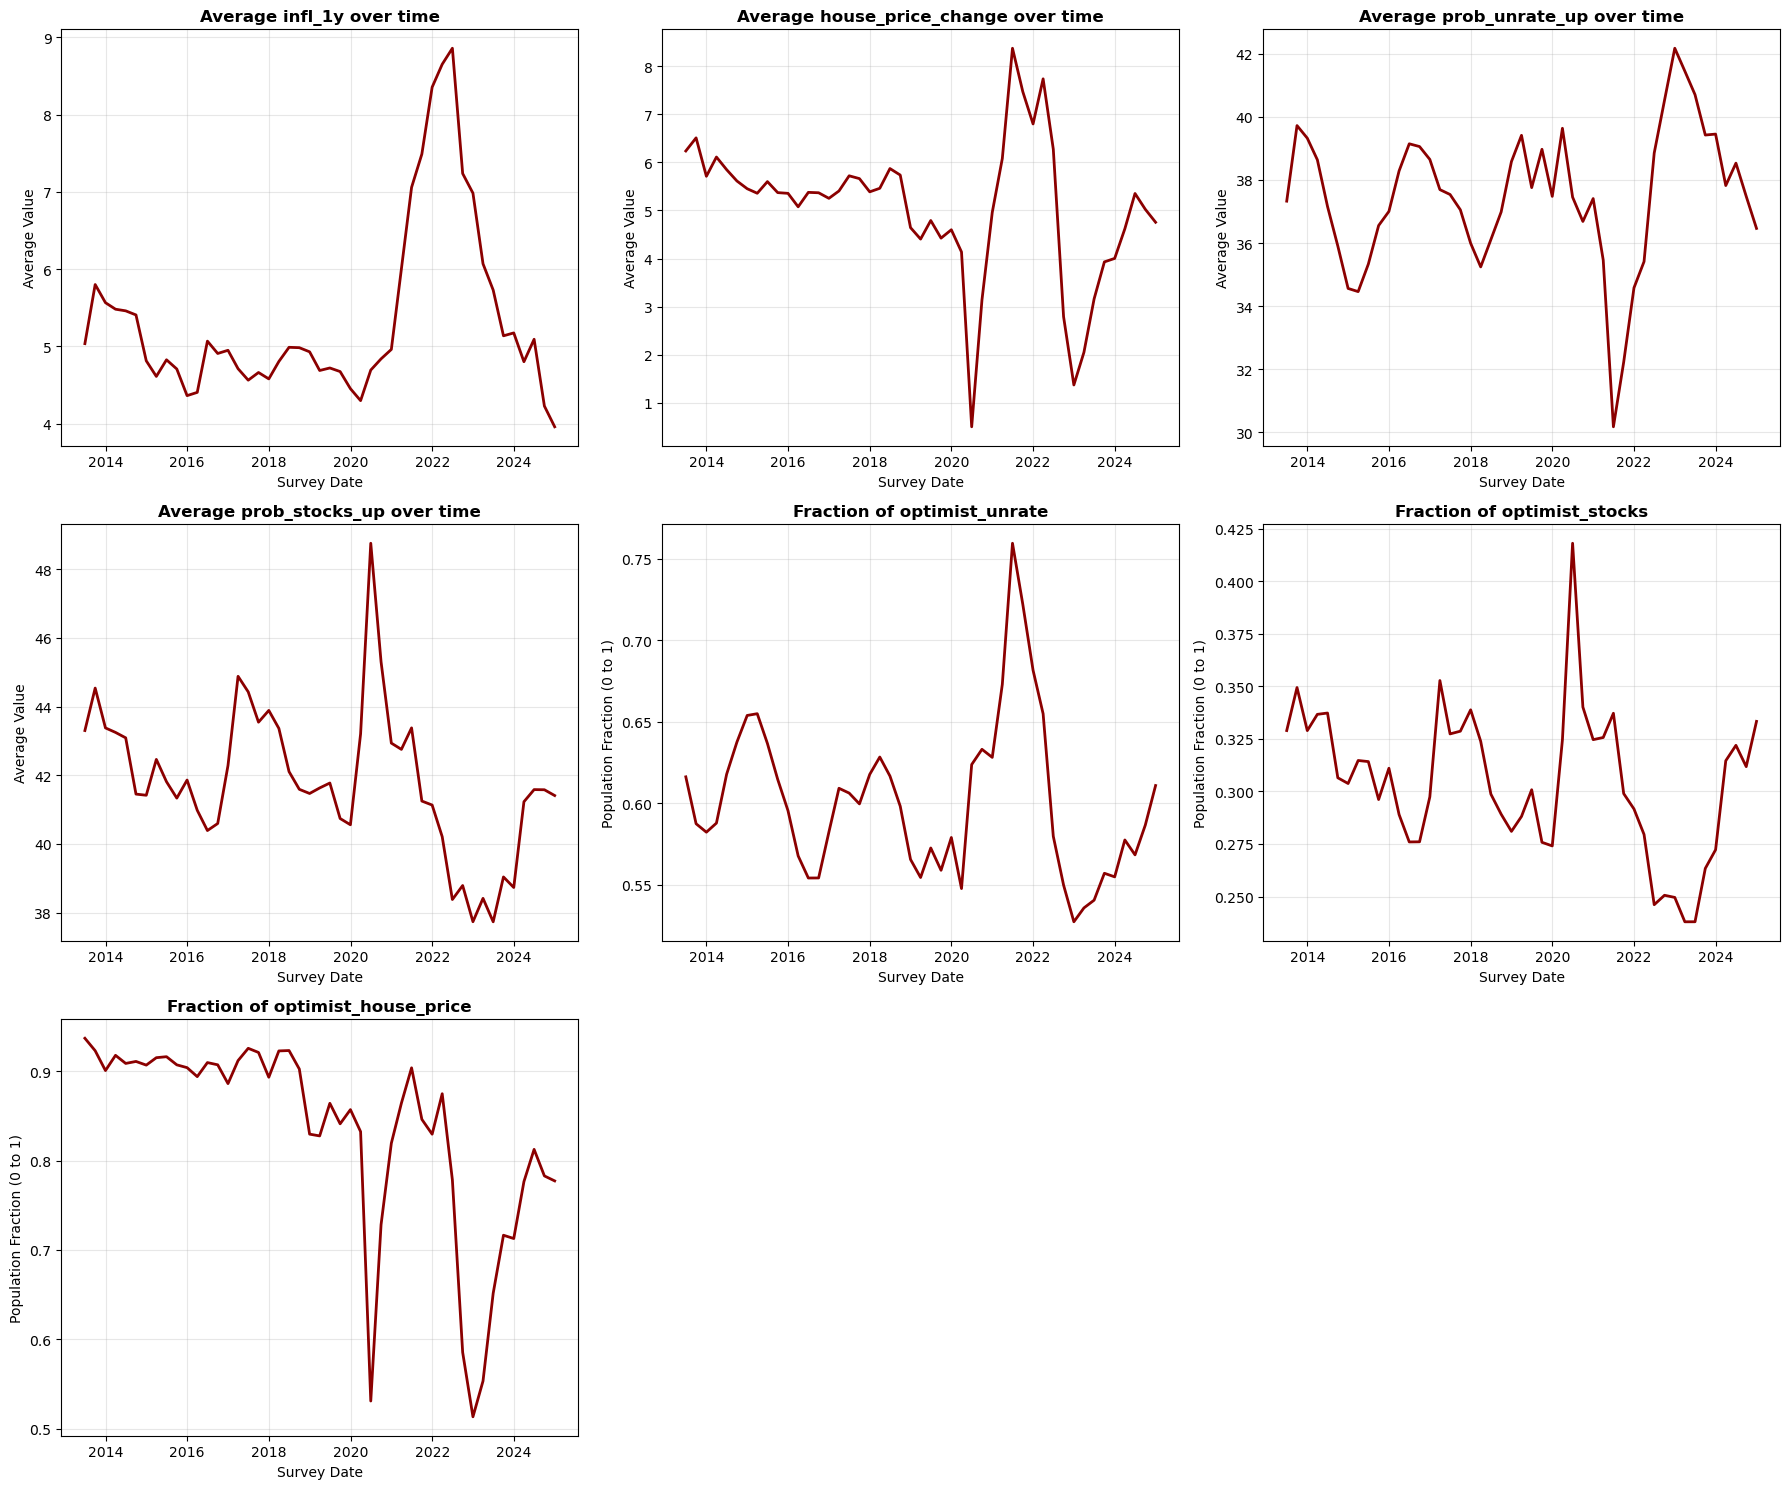

In [13]:
# Compute average expectations and optimism rates by date
time_series_df = df_sce.set_index('date').resample('QE').mean(numeric_only=True)

optimist_vars = ['optimist_unrate', 'optimist_stocks', 'optimist_house_price']

# Combine continuous and binary variables in one plotting list
all_vars_to_plot = expectation_vars + optimist_vars

n_cols = 3
n_rows = int(np.ceil(len(all_vars_to_plot) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(all_vars_to_plot):
    axes[i].plot(time_series_df.index, time_series_df[col], color='darkred', linewidth=2)
    
    if col in optimist_vars:
        axes[i].set_title(f'Fraction of {col}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Population Fraction (0 to 1)')
    else:
        axes[i].set_title(f'Average {col} over time', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Average Value')
        
    axes[i].set_xlabel('Survey Date')
    axes[i].grid(True, alpha=0.3)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Part 4 - Exploratory Data Analysis (Macro/Finance)
In this part, we study the macroeconomic and financial variables that were merged into the SCE data in Part 2.

We first plot the variables in levels and then plot the transformed variables in changes. After that, we compute simple correlations between the SCE expectation variables and the macro/finance variables.

### 4.1 Original Macro Variables (Base Levels)
Time series arrays tracking the absolute raw rates and levels of our economic covariates seamlessly bound within the SCE survey timeframe.

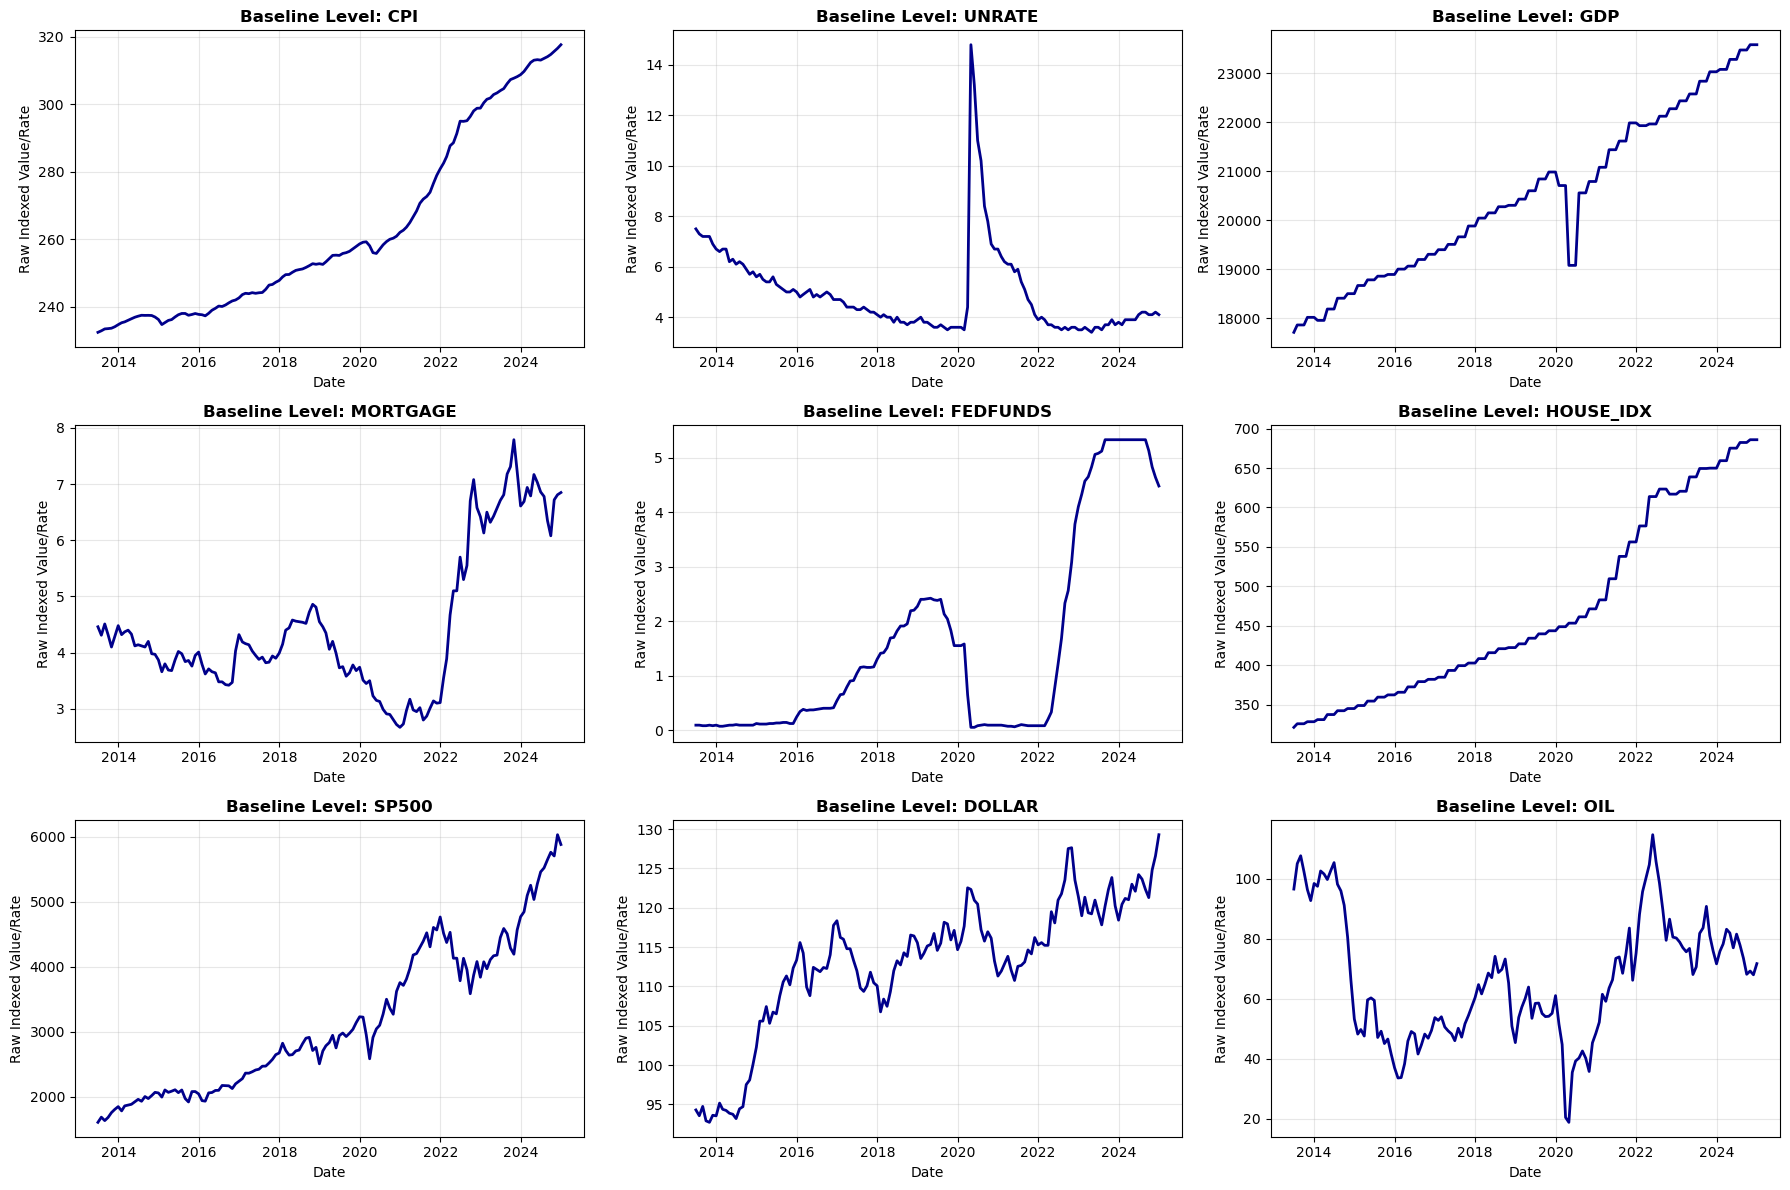

In [14]:
# Plot the original macroeconomic and financial variables in levels

# Variables in levels
base_macro_vars = ['cpi', 'unrate', 'gdp', 'mortgage', 'fedfunds', 'house_idx', 'sp500', 'dollar', 'oil']

# Restrict the macro and financial data to the SCE sample period
start_date = df_sce['date'].min()
end_date = df_sce['date'].max()

macro_plot_df = df_macro[(df_macro['date'] >= start_date) & (df_macro['date'] <= end_date)]

n_cols = 3
n_rows = int(np.ceil(len(base_macro_vars)) / n_cols)

# Create a grid of time series plots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(base_macro_vars):
    if col in macro_plot_df.columns:
        axes[i].plot(macro_plot_df['date'], macro_plot_df[col], color='darkblue', linewidth=2)
        axes[i].set_title(f'Baseline Level: {col.upper()}', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Raw Indexed Value/Rate')
        axes[i].set_xlabel('Date')
        axes[i].grid(axis='both', alpha=0.3)

# Remove unused subplots
for j in range(len(base_macro_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The plots in levels summarize the broad macroeconomic and financial environment over the survey period. They provide the baseline context in which households formed their expectations.

### 4.2 Plot Engineered Variables (Relative vs Absolute Differences)
We now plot the 12-month macroeconomic changes constructed in Part 2. For rate-based variables, we use absolute differences, while for indices and price variables, we use relative percentage changes.

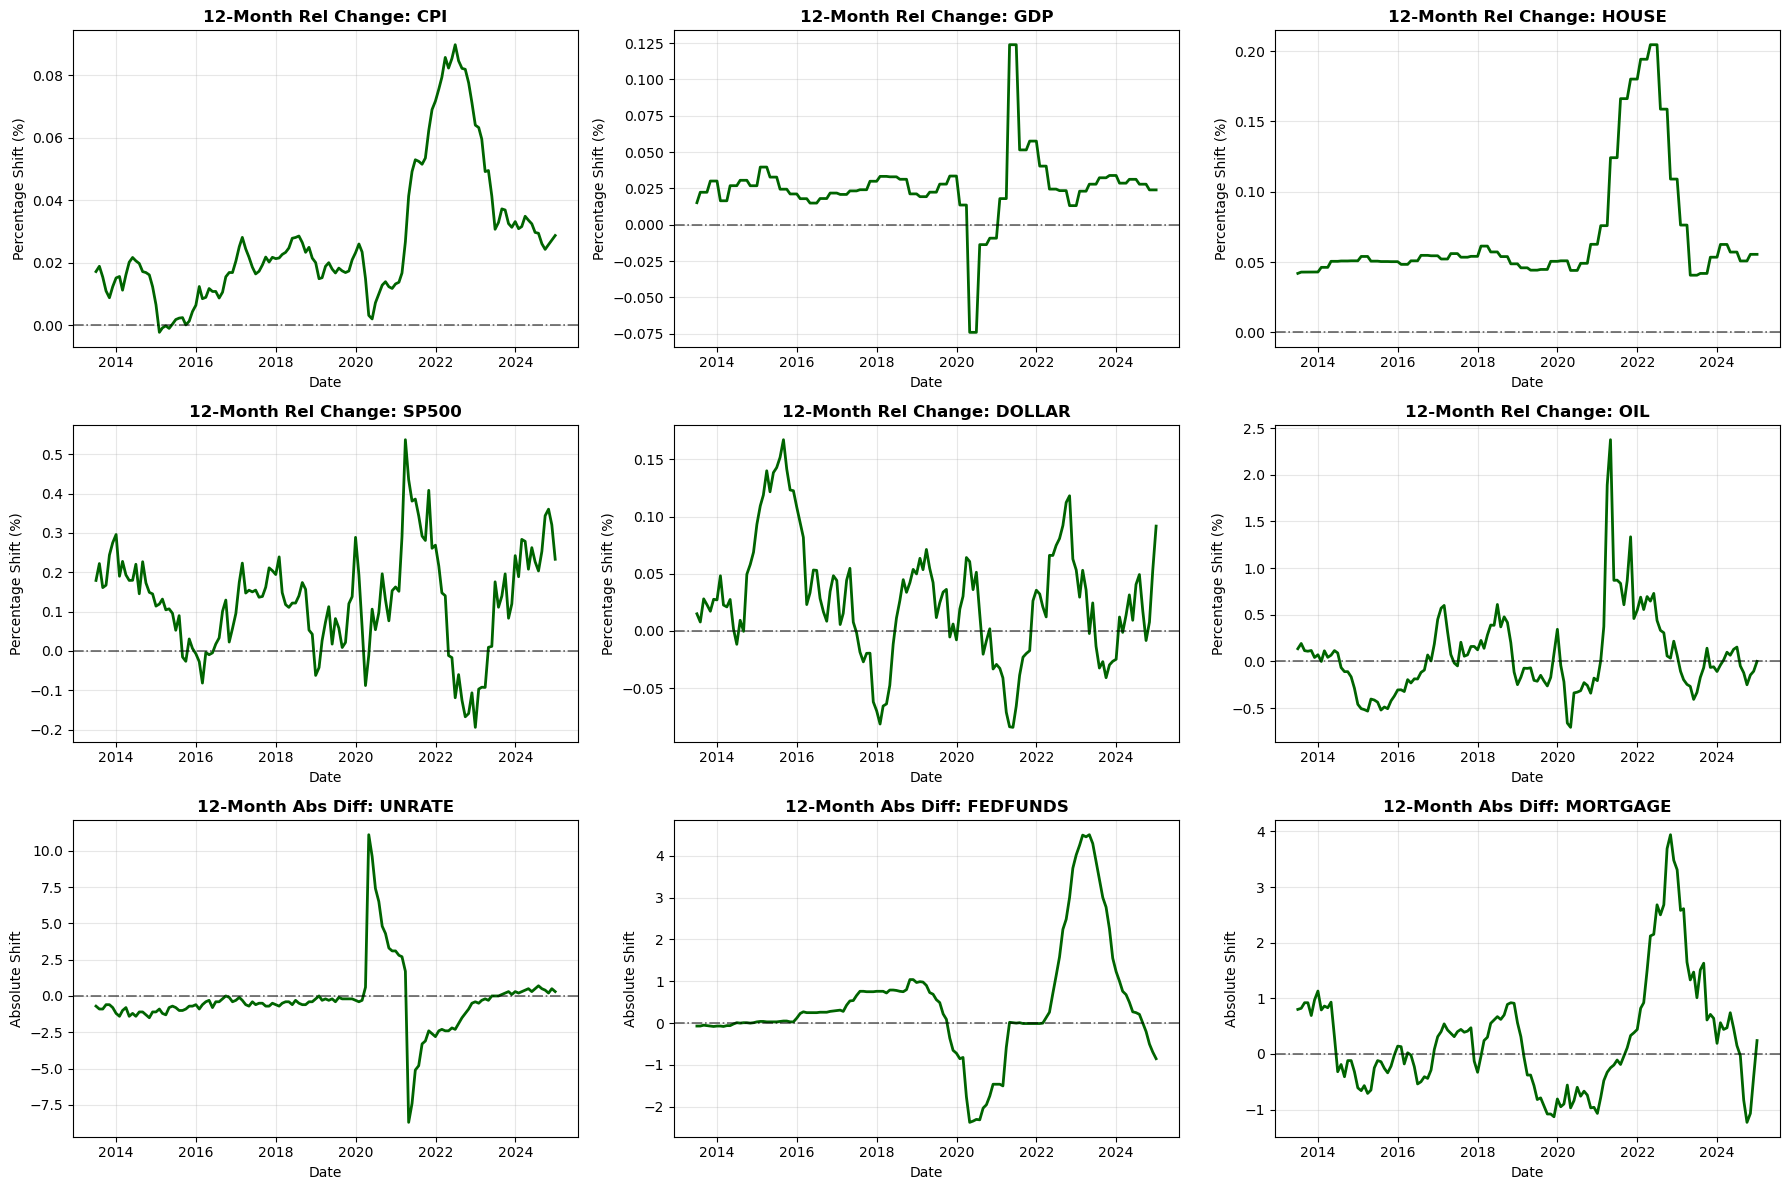

In [15]:
# Plot the transformed macroeconomic and financial variables in changes

# Select the 12-month indicators used in the analysis
momentum_vars = [
    'cpi_pct12', 'gdp_pct12', 'house_idx_pct12', 
    'sp500_pct12', 'dollar_pct12', 'oil_pct12', 
    'unrate_diff12', 'fedfunds_diff12', 'mortgage_diff12'
]

n_cols = 3
n_rows = int(np.ceil(len(momentum_vars)) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(momentum_vars):
    if col in macro_plot_df.columns:
        axes[i].plot(macro_plot_df['date'], macro_plot_df[col], color='darkgreen', linewidth=2)
        
        # Subtly format styling dynamically based on statistical trait
        if 'pct' in col:
            axes[i].set_title(f'12-Month Rel Change: {col.split("_")[0].upper()}', fontsize=12, fontweight='bold')
            axes[i].set_ylabel('Percentage Shift (%)')
        else:
            axes[i].set_title(f'12-Month Abs Diff: {col.split("_")[0].upper()}', fontsize=12, fontweight='bold')
            axes[i].set_ylabel('Absolute Shift')
            
        axes[i].set_xlabel('Date')
        axes[i].axhline(0, color='black', linestyle='-.', linewidth=1.2, alpha=0.6)
        axes[i].grid(axis='both', alpha=0.3)

# Remove unused subplots
for j in range(len(momentum_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

The transformed variables in changes are often more informative in a predictive setting than the raw levels. Growth rates and first differences capture recent movements in macroeconomic and financial conditions more directly and may therefore be more closely related to changes in household expectations.

### 4.3 Correlation Tables (Expectation vs. Macro Indicators)
We examine the relationship between the four continuous expectation variables and the macroeconomic variables used later in the models.

In [16]:
# 4.3 Print out detailed mathematical correlation structures

# We assemble the collective list of macro features we are integrating into our models
# We employ the target robust indicators mathematically defined in 4.1 and 4.2
all_macro_features = base_macro_vars + momentum_vars

# Utilizing IPython Display to output clean HTML tables per variable
for target in expectation_vars:
    print(f"\n{'='*65}")
    print(f" Macroeconomic variables most highly correlated with '{target.upper()}' ")
    print(f"{'='*65}")
    
    # We utilize pandas .corrwith() which is computationally superior for 1-to-many dimensional arrays
    # rather than building out the complete NxN generalized .corr() matrix.
    corr_series = df_final[all_macro_features].corrwith(df_final[target])
    
    # We sort by the ABSOLUTE magnitude of the relationship.
    # In regression, a dense -0.7 inverse correlation is just as predictive as a +0.7 positive correlation!
    corr_sorted = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)
    
    # We cast to a dataframe dynamically, format as styled HTML, and output the absolute top-10 parameters
    df_output = corr_sorted.head(10).to_frame(name='Coefficient Rate')
    display(df_output.style.background_gradient(cmap='coolwarm', axis=0).format("{:.4f}"))


 Macroeconomic variables most highly correlated with 'INFL_1Y' 


,Coefficient Rate
house_idx_pct12,0.1263
cpi_pct12,0.1119
oil_pct12,0.0853
oil,0.0731
mortgage_diff12,0.0684
unrate_diff12,-0.0582
sp500,0.0521
gdp_pct12,0.0512
house_idx,0.0509
cpi,0.0448



 Macroeconomic variables most highly correlated with 'HOUSE_PRICE_CHANGE' 


,Coefficient Rate
sp500_pct12,0.1332
gdp_pct12,0.1122
oil_pct12,0.1057
unrate_diff12,-0.1032
dollar,-0.0944
fedfunds,-0.0879
mortgage,-0.0820
fedfunds_diff12,-0.0649
cpi,-0.0626
dollar_pct12,-0.0599



 Macroeconomic variables most highly correlated with 'PROB_UNRATE_UP' 


,Coefficient Rate
sp500_pct12,-0.0748
mortgage_diff12,0.0540
mortgage,0.0538
fedfunds_diff12,0.0492
fedfunds,0.0442
gdp_pct12,-0.0415
oil_pct12,-0.0414
dollar_pct12,0.0331
unrate,-0.0318
dollar,0.0268



 Macroeconomic variables most highly correlated with 'PROB_STOCKS_UP' 


,Coefficient Rate
fedfunds_diff12,-0.0657
unrate,0.0572
cpi_pct12,-0.0540
cpi,-0.0506
house_idx,-0.0503
mortgage,-0.0496
gdp,-0.0483
mortgage_diff12,-0.0476
fedfunds,-0.0445
sp500,-0.0377


## Part 5 - Predicting Continuous Expectations
In this section, we predict the four continuous expectation variables `infl_1y`, `house_price_change`, `prob_unrate_up`, and `prob_stocks_up`.

Following the assignment, we split the sample into a training period (all observations before `2024-01-01`) and a test period (`2024-01-01` to `2024-12-31`). We estimate Linear Regression, Ridge, and Lasso models for each target. For Ridge and Lasso, hyperparameters are selected by cross-validation.

For each target, we run the analysis twice:
1. using only macro/finance variables, and
2. using the macro variables plus selected individual-level SCE variables.

We report the cross-validated hyperparameter choice when applicable, evaluate out-of-sample performance using RMSE and \(R^2\), and visualize both the regularization paths and the average actual-versus-predicted time series.

### 5.1 Environment Setup & Feature Groups
We first prepare the modeling dataset for the continuous prediction exercise. This includes encoding categorical variables, defining the train/test split at `2024-01-01`, and constructing the two feature sets required by the assignment: a macro-only specification and a macro-plus-SCE specification.

In [17]:
# 5.1 Environment Configuration & Preprocessing
warnings.filterwarnings('ignore') # Filter standard scikit-learn warnings

df_model = pd.get_dummies(df_final, columns=[c for c in initial_wave_vars if c in ['educ']], drop_first=True)

train_mask = df_model['date'] < '2024-01-01'
df_train = df_model[train_mask]
df_test = df_model[~train_mask]

feature_sets = {
    'Macro Only': all_macro_features,
    'Macro + SCE': all_macro_features + [c for c in df_model.columns if c.startswith('educ_')] + [c for c in initial_wave_vars if c != 'educ']
}

### 5.2 Isolated Helper Functions
This section defines the helper functions used in Part 5. The first function fits the continuous-outcome models and stores the quantities needed for evaluation. The plotting helpers are then used to display the Ridge and Lasso validation curves and the time-series comparison between average actual and predicted values.

In [18]:
# Helper Function 1: Machine Learning Evaluation Architecture (No Graphical Overlay)
def calculate_continuous_regression(target, feature_set_name, features):
    df_eval = df_model[['date', target] + features].dropna().copy()

    mask = df_eval['date'] < '2024-01-01'
    X_train, y_train = df_eval.loc[mask, features], df_eval.loc[mask, target]
    X_test, y_test   = df_eval.loc[~mask, features], df_eval.loc[~mask, target]

    models = {
        'LinearRegression': LinearRegression(),
        'RidgeCV': RidgeCV(alphas=np.logspace(-2, 4, 30), store_cv_results=True),
        'LassoCV': LassoCV(alphas=np.logspace(-4, 2, 30), cv=5, max_iter=20000, n_jobs=-1, selection='random')
    }

    outputs = []

    for model_name, estimator in models.items():
        # Standardize inputs before estimation
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', estimator)
        ])
        pipe.fit(X_train, y_train)
        fitted = pipe.named_steps['model']

        best_alpha = None
        cv_validation_mse = None
        alpha_grid = None
        cv_curve_mse = None

        if model_name in ['RidgeCV', 'LassoCV']:
            best_alpha = fitted.alpha_

            if model_name == 'RidgeCV':
                alpha_grid = np.array(fitted.alphas)

                # Robust handling across sklearn versions
                if hasattr(fitted, 'cv_results_') and fitted.cv_results_ is not None:
                    if isinstance(fitted.cv_results_, dict):
                        if 'mean_test_score' in fitted.cv_results_:
                            raw_scores = np.array(fitted.cv_results_['mean_test_score'])
                            cv_curve_mse = np.abs(raw_scores) if np.mean(raw_scores) <= 0 else raw_scores
                            cv_validation_mse = np.min(cv_curve_mse)
                    else:
                        raw_scores = np.array(fitted.cv_results_)
                        if raw_scores.ndim >= 2:
                            cv_curve_mse = np.mean(raw_scores, axis=0)
                            cv_validation_mse = np.min(cv_curve_mse)

            elif model_name == 'LassoCV':
                alpha_grid = np.array(fitted.alphas_)
                cv_curve_mse = np.mean(fitted.mse_path_, axis=1)
                cv_validation_mse = np.min(cv_curve_mse)

        y_test_pred = pipe.predict(X_test)
        y_all_pred = pipe.predict(df_eval[features])

        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
        r2_test = r2_score(y_test, y_test_pred)

        plot_df = df_eval[['date', target]].copy()
        plot_df['predicted'] = y_all_pred
        plot_df['sample'] = np.where(plot_df['date'] < '2024-01-01', 'Train', 'Test')

        outputs.append({
            'Target Variable': target,
            'Feature Depth': feature_set_name,
            'Regressive Algorithm': model_name,
            'Optimized Alpha': best_alpha,
            'Validation CV MSE': cv_validation_mse,
            'Alpha Grid': alpha_grid,
            'CV Curve MSE': cv_curve_mse,
            'Test OOS RMSE': rmse_test,
            'Test OOS R2': r2_test,
            'model_pipeline': pipe,
            'df_eval_used': df_eval,
            'features_used': features,
            'plot_df': plot_df
        })

    return outputs

In [19]:
# Helper Function 2: Validation Curve Renderer
def plot_validation_curve(model_output_entry, ax=None):
    pipe = model_output_entry['model_pipeline']
    m_name = model_output_entry['Regressive Algorithm']
    target = model_output_entry['Target Variable']
    fitted = pipe.named_steps['model']

    if m_name == 'LinearRegression':
        if ax is not None:
            ax.text(0.5, 0.5,
                    f'No validation curve for LinearRegression\n({target})',
                    ha='center', va='center', fontsize=10)
            ax.set_axis_off()
            return ax
        else:
            print(f"LinearRegression possesses no hyperparameter iterations to natively trace/plot for {target}.")
            return None

    if m_name == 'RidgeCV':
        if hasattr(fitted, 'cv_results_') and isinstance(fitted.cv_results_, dict):
            cv_mse = fitted.cv_results_['mean_test_score']
            if np.mean(cv_mse) <= 0:
                cv_mse = -cv_mse
        else:
            res = fitted.cv_results_ if hasattr(fitted, 'cv_results_') else fitted.cv_values_
            cv_mse = np.mean(res, axis=0)

        alphas = fitted.alphas
        color = 'royalblue'

    elif m_name == 'LassoCV':
        cv_mse = np.mean(fitted.mse_path_, axis=1)
        alphas = fitted.alphas_
        color = 'firebrick'

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 3))

    ax.plot(np.log10(alphas), cv_mse, marker='s', markersize=4, color=color)
    ax.axvline(np.log10(model_output_entry['Optimized Alpha']),
               linestyle='--', color='gray', alpha=0.8)
    ax.set_title(f'{m_name} Cross-Validation Path ({target})', fontsize=10, fontweight='bold')
    ax.set_xlabel('log10(Alpha Penalty Strength)')
    ax.set_ylabel('Mean Squared Error (MSE)')
    ax.grid(True, alpha=0.3)

    return ax

In [20]:
# Helper Function 3: Time-Series Predictor Overlay Graphics
def plot_forecast_overlay(model_output_entry, ax=None):
    pipe = model_output_entry['model_pipeline']
    df_eval = model_output_entry['df_eval_used'].copy()
    features = model_output_entry['features_used']
    target = model_output_entry['Target Variable']
    model_name = model_output_entry['Regressive Algorithm']
    f_set = model_output_entry['Feature Depth']
    
    X_all = df_eval[features]
    df_eval['y_predicted'] = pipe.predict(X_all)
    
    ts_act = df_eval.groupby('date')[target].mean()
    ts_pred = df_eval.groupby('date')['y_predicted'].mean()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    
    ax.plot(ts_act.index, ts_act.values, label='Actual Realized Average', color='gray', alpha=0.7)
    ax.plot(ts_pred.index, ts_pred.values, label='Model Expected Horizon', color='teal', linewidth=2)
    ax.axvline(pd.to_datetime('2024-01-01'), color='red', linestyle='--', label='Validation Boundary (2024)')
    ax.set_title(f"Forecaster Output: {target} | {model_name} ({f_set})", fontsize=11, fontweight='bold')
    ax.set_xlabel('Global Timeline')
    ax.set_ylabel('Levels Recorded')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    return ax

### 5.3 Model Execution Loop
We now estimate the full set of Part 5 models. For each of the four continuous targets, we fit the models under both feature specifications and collect the resulting performance metrics, selected hyperparameters, and plotting objects in a master results list.

In [21]:
# Collect all model outputs across targets and feature sets.
master_results_pt5 = []

# Run the Part 5 estimation loop
for target in expectation_vars:
    for feature_name, feature_data in feature_sets.items():
        results = calculate_continuous_regression(target, feature_name, feature_data)
        master_results_pt5.extend(results)
        
print("Execution Completed cleanly!")
print(f"Total Models Generated: {len(master_results_pt5)}")

Execution Completed cleanly!
Total Models Generated: 24


### 5.4 Graph Visualization Validation
For each target variable, we summarize the regularized-model tuning results and the time-series fit in a single figure. The left and middle panels show the Ridge and Lasso validation curves, while the right panel shows the average actual and predicted series for the best-performing specification for that target.

In [22]:
def make_target_summary_figure(target_var, results_store):
    # pick best Ridge model for this target
    ridge_candidates = [
        m for m in results_store
        if m['Target Variable'] == target_var and m['Regressive Algorithm'] == 'RidgeCV'
    ]
    ridge_model = min(ridge_candidates, key=lambda x: x['Test OOS RMSE'])

    # pick best Lasso model for this target
    lasso_candidates = [
        m for m in results_store
        if m['Target Variable'] == target_var and m['Regressive Algorithm'] == 'LassoCV'
    ]
    lasso_model = min(lasso_candidates, key=lambda x: x['Test OOS RMSE'])

    # pick best overall model for overlay
    overall_candidates = [
        m for m in results_store
        if m['Target Variable'] == target_var
    ]
    best_model = min(overall_candidates, key=lambda x: x['Test OOS RMSE'])

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    plot_validation_curve(ridge_model, ax=axes[0])
    axes[0].set_title(f"RidgeCV Validation Curve\n{target_var}")

    plot_validation_curve(lasso_model, ax=axes[1])
    axes[1].set_title(f"LassoCV Validation Curve\n{target_var}")

    plot_forecast_overlay(best_model, ax=axes[2])
    axes[2].set_title(
        f"Actual vs Predicted\nBest: {best_model['Regressive Algorithm']} | {best_model['Feature Depth']}"
    )

    fig.suptitle(f"Part 5 Results for {target_var}", fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    return fig

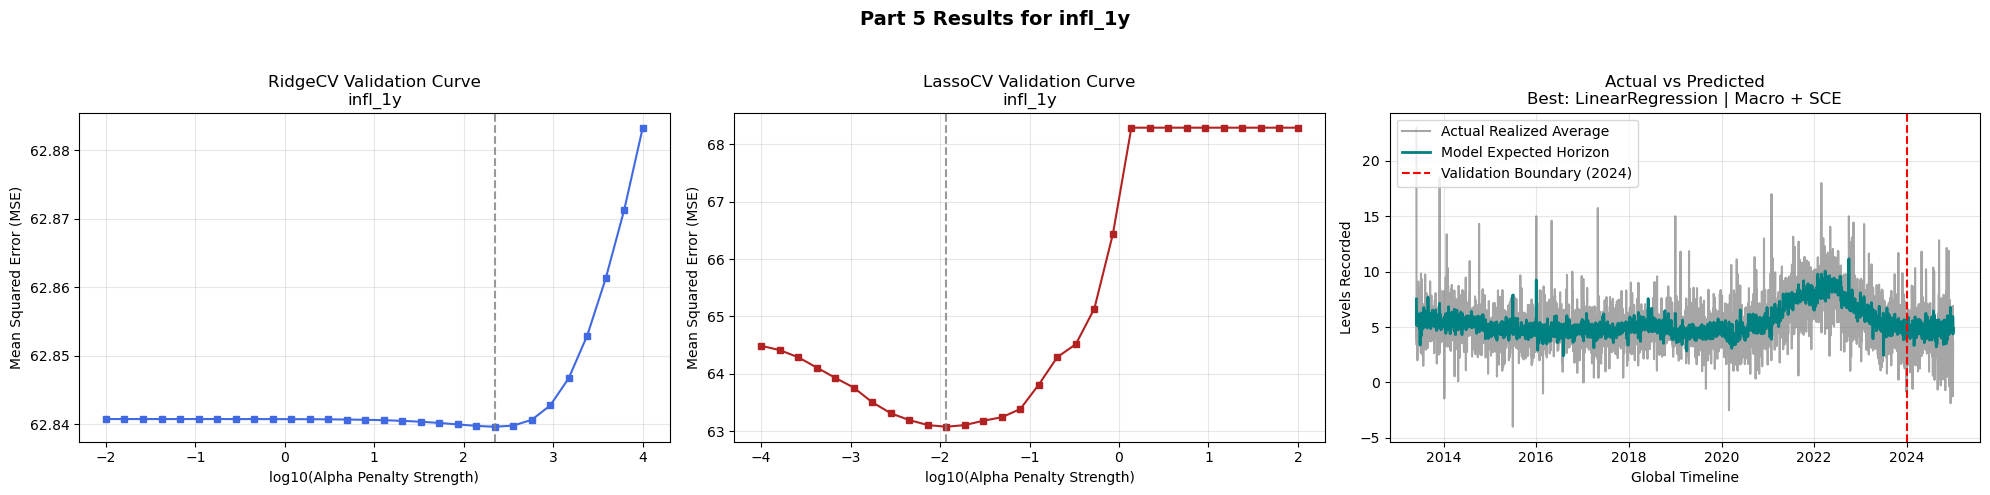

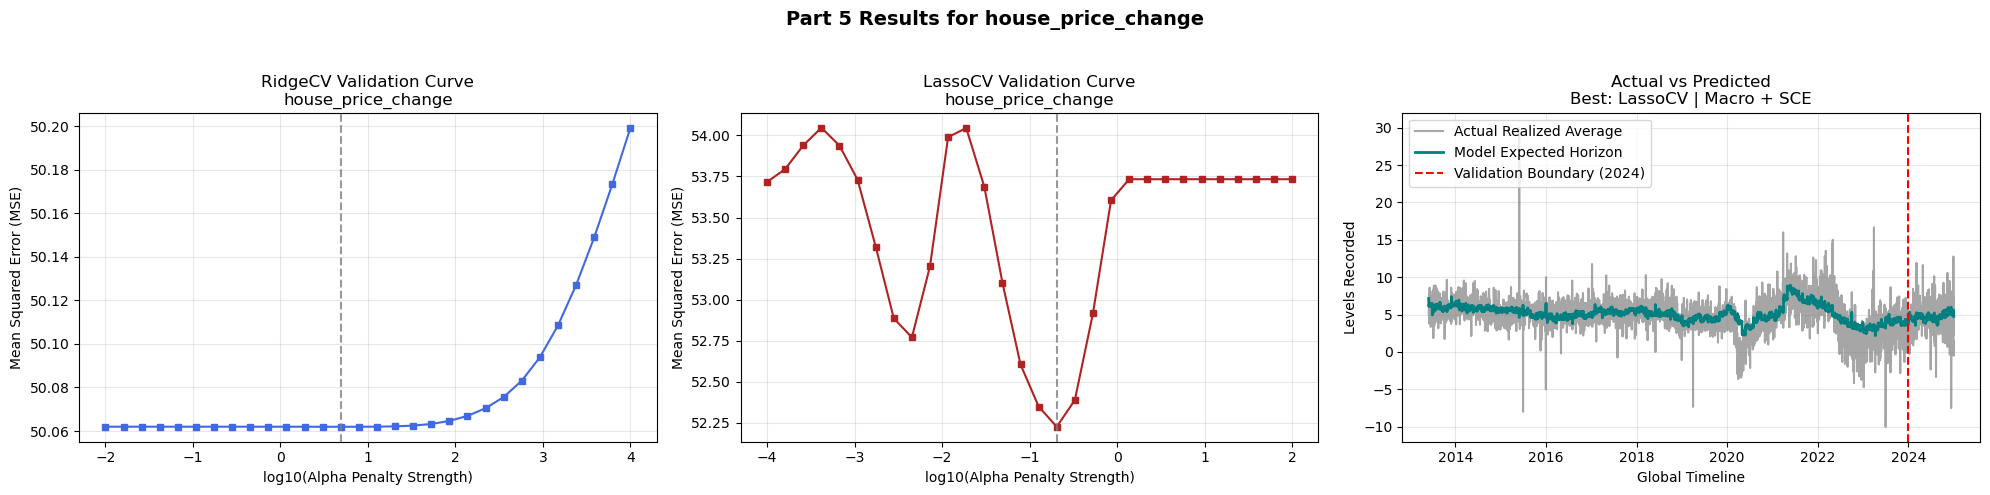

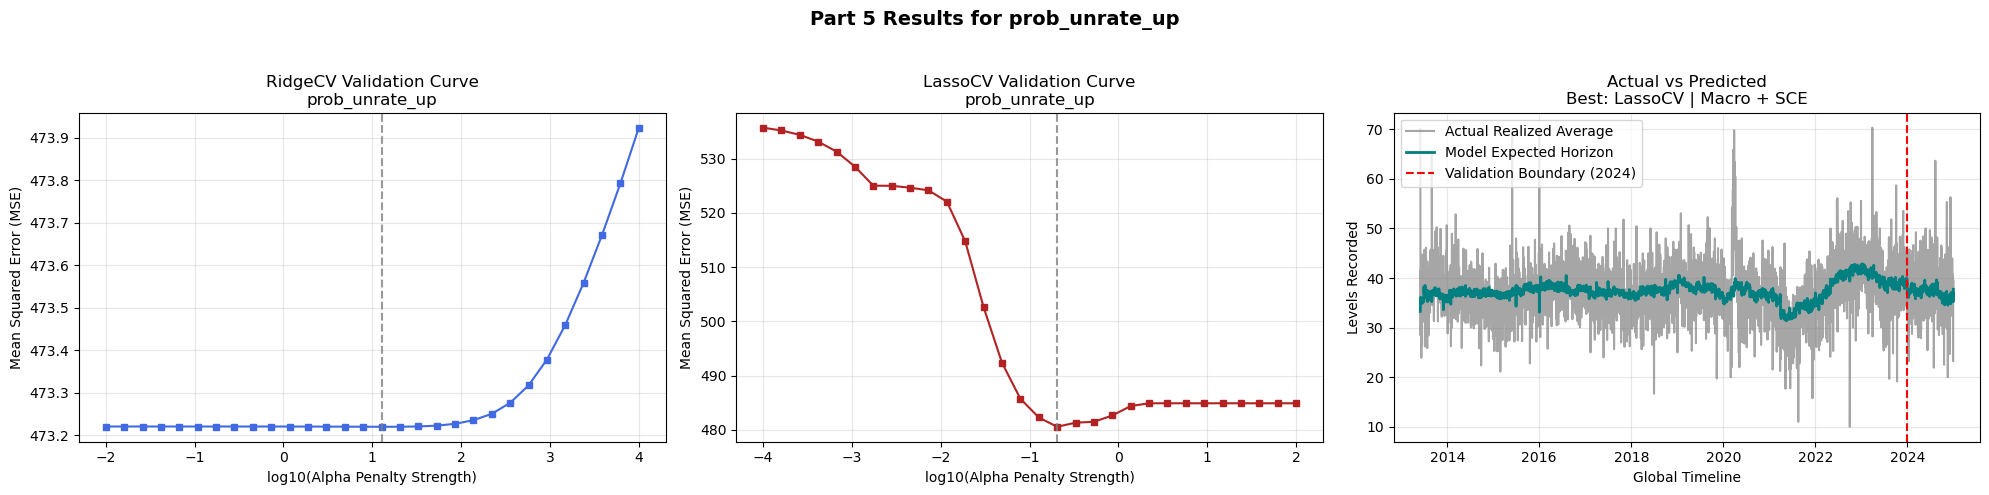

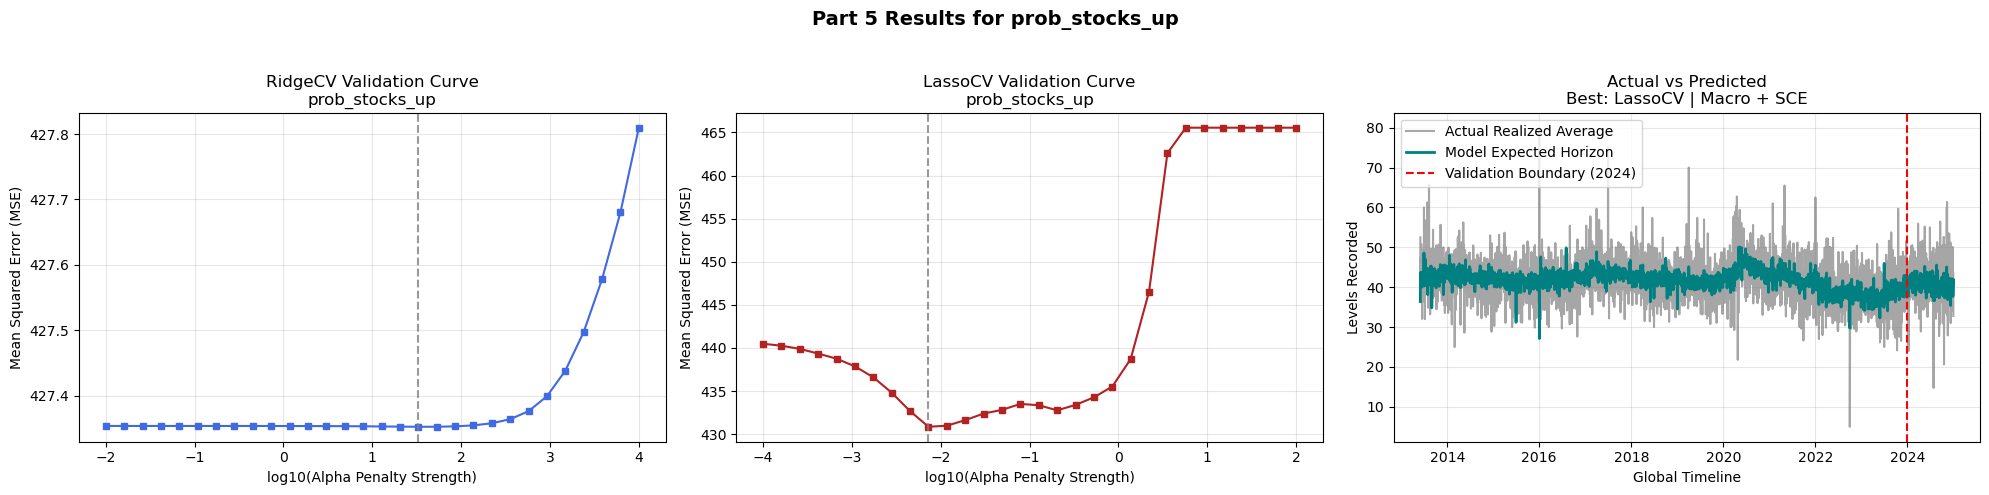

In [23]:
# Render one figure per target variable.
for target in expectation_vars:
    make_target_summary_figure(target, master_results_pt5)
    plt.show()

### 5.5 Leaderboard Results Matrix
The table below summarizes the Part 5 results across all targets, feature sets, and model classes. We report the selected hyperparameter when applicable, the cross-validated validation MSE, and the out-of-sample test metrics. Lower RMSE indicates better predictive performance.

In [24]:
# 5.5 Render strictly tabular Leaderboard mappings
exclude_cols = [
    'model_pipeline',
    'df_eval_used',
    'features_used',
    'Alpha Grid',
    'CV Curve MSE',
    'plot_df'
]

output_df = pd.DataFrame([
    {k: v for k, v in obj.items() if k not in exclude_cols}
    for obj in master_results_pt5
])

column_order = [
    'Target Variable',
    'Feature Depth',
    'Regressive Algorithm',
    'Optimized Alpha',
    'Validation CV MSE',
    'Test OOS RMSE',
    'Test OOS R2'
]

output_df = output_df[column_order].sort_values(
    by=['Target Variable', 'Test OOS RMSE'],
    ascending=[True, True]
)

output_df.style.format(precision=4).background_gradient(
    subset=['Test OOS RMSE'],
    cmap='viridis_r'
)

,Target Variable,Feature Depth,Regressive Algorithm,Optimized Alpha,Validation CV MSE,Test OOS RMSE,Test OOS R2
11,house_price_change,Macro + SCE,LassoCV,0.2043,52.2255,7.9255,0.0250
10,house_price_change,Macro + SCE,RidgeCV,4.8939,50.0620,7.9399,0.0214
9,house_price_change,Macro + SCE,LinearRegression,nan,nan,7.9400,0.0214
8,house_price_change,Macro Only,LassoCV,0.2043,53.4279,8.0376,-0.0028
6,house_price_change,Macro Only,LinearRegression,nan,nan,8.0713,-0.0112
7,house_price_change,Macro Only,RidgeCV,4.8939,51.6516,8.0715,-0.0113
3,infl_1y,Macro + SCE,LinearRegression,nan,nan,8.8333,0.0410
4,infl_1y,Macro + SCE,RidgeCV,221.2216,62.8396,8.8350,0.0406
5,infl_1y,Macro + SCE,LassoCV,0.0117,63.0745,8.8907,0.0284
0,infl_1y,Macro Only,LinearRegression,nan,nan,9.0170,0.0006


Across the four continuous targets, performance differences across model classes are modest. Ridge and Lasso provide a disciplined way to tune regularization, but the gains relative to simple linear regression are generally limited. Comparing the macro-only and macro-plus-SCE specifications shows whether adding individual-level information materially improves out-of-sample accuracy; in most cases, this effect should be evaluated using the changes in test RMSE and \(R^2\) reported in the table above.

## Part 6 - Predicting Binary Optimism Variables
In this section, we repeat the predictive exercise from Part 5 using the three binary optimism variables `optimist_unrate`, `optimist_stocks`, and `optimist_house_price` as targets.

Because these outcomes are binary, the task is now a classification problem. Following the assignment, we estimate at least Logistic Regression and Random Forest models. Hyperparameters are selected by cross-validation where applicable.

As in Part 5, we run the analysis twice for each target:
1. using only macro/finance variables, and
2. using the macro variables plus selected individual-level SCE variables.

We report the selected hyperparameters together with the training- and test-sample classification metrics, and we visualize the actual and predicted fractions of optimists over time with the 2024 train/test split marked explicitly.

### 6.1 Classification Model Setup
This section defines the helper function used to estimate the classification models in Part 6. For each target and feature specification, we fit Logistic Regression and Random Forest models on the pre-2024 training sample and evaluate their performance on the 2024 test sample.

In [25]:
# Helper Function 1: Core Classification Engine Definition
def calculate_binary_classification(target, feature_set_name, features):
    df_eval = df_model[['date', target] + features].dropna().copy()
    
    # Establish strict OOS boundaries globally
    mask = df_eval['date'] < '2024-01-01'
    X_train, y_train = df_eval.loc[mask, features], df_eval.loc[mask, target]
    X_test, y_test   = df_eval.loc[~mask, features], df_eval.loc[~mask, target]
    
    outputs = []
    class_models = ['Logistic Regression', 'Random Forest']
    
    for m_name in class_models:
        if m_name == 'Logistic Regression':
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', LogisticRegressionCV(
                    Cs=10, cv=5, penalty='l2', solver='lbfgs',
                    max_iter=2000, n_jobs=-1
                ))
            ])
            pipe.fit(X_train, y_train)
            fitted = pipe
            best_param = f"Opt. C: {pipe.named_steps['model'].C_[0]:.4f}"
            
        elif m_name == 'Random Forest':
            rf_pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', RandomForestClassifier(random_state=42))
            ])
            param_grid = {
                'model__n_estimators': [50, 100],
                'model__max_depth': [5, 10]
            }
            search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='f1', n_jobs=-1)
            search.fit(X_train, y_train)
            fitted = search.best_estimator_
            best_param = str(search.best_params_)

        # Hard predictions
        y_train_hat = fitted.predict(X_train)
        y_test_hat = fitted.predict(X_test)

        # Probability predictions for plotting
        y_all_prob = fitted.predict_proba(df_eval[features])[:, 1]

        plot_df = df_eval[['date', target]].copy()
        plot_df['pred_prob'] = y_all_prob
        plot_df['sample'] = np.where(plot_df['date'] < '2024-01-01', 'Train', 'Test')
        
        outputs.append({
            'Target': target,
            'Features': feature_set_name,
            'Classifier': m_name,
            'Opt Parameters': best_param,

            'Train Acc': accuracy_score(y_train, y_train_hat),
            'Train Prec': precision_score(y_train, y_train_hat, zero_division=0),
            'Train Rec': recall_score(y_train, y_train_hat, zero_division=0),
            'Train F1': f1_score(y_train, y_train_hat, zero_division=0),

            'Test Acc': accuracy_score(y_test, y_test_hat),
            'Test Prec': precision_score(y_test, y_test_hat, zero_division=0),
            'Test Rec': recall_score(y_test, y_test_hat, zero_division=0),
            'Test F1': f1_score(y_test, y_test_hat, zero_division=0),

            'model_pipeline': fitted,
            'df_eval_used': df_eval,
            'features_used': features,
            'plot_df': plot_df
        })
    return outputs

The following helper function plots the average actual fraction of optimists and the average predicted probability over time. Predicted probabilities are used rather than hard class predictions so that the plotted series reflects the model’s expected optimism rate at each date.

In [26]:
# Helper Function 2: Fractional Probability Visualizations
def plot_fractional_forecast(model_output_entry, ax=None):
    pipe = model_output_entry['model_pipeline']
    df_eval = model_output_entry['df_eval_used'].copy()
    features = model_output_entry['features_used']
    target = model_output_entry['Target']
    model_name = model_output_entry['Classifier']
    f_set = model_output_entry['Features']
    
    X_all = df_eval[features]
    df_eval['y_predicted'] = pipe.predict_proba(X_all)[:, 1]
    
    ts_act = df_eval.groupby('date')[target].mean()
    ts_pred = df_eval.groupby('date')['y_predicted'].mean()
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    
    ax.plot(ts_act.index, ts_act.values, label='Actual Optimist Fraction', color='gray', alpha=0.7)
    ax.plot(ts_pred.index, ts_pred.values, label='Predicted Optimist Fraction', color='purple', linewidth=2)
    ax.axvline(pd.to_datetime('2024-01-01'), color='red', linestyle='--', label='Validation Boundary (2024)')
    ax.set_xlabel('Survey Timeline Tracker')
    ax.set_ylabel('Optimist Fraction (0-1)')
    ax.legend(loc='upper left')
    ax.grid(alpha=0.3)
    
    return ax

### 6.2 Classification Model Execution
We now estimate the full set of Part 6 models. For each binary target, we fit both classifier families under the two feature specifications and store the resulting metrics, selected hyperparameters, and plotting objects in a master results list.

In [27]:
# Collect all classification outputs across targets and feature sets.
master_results_pt6 = []
optimist_vars = ['optimist_unrate', 'optimist_stocks', 'optimist_house_price']

# Run the full Part 6 estimation loop:
for target in optimist_vars:
    for feature_name, feature_data in feature_sets.items():
        results = calculate_binary_classification(target, feature_name, feature_data)
        master_results_pt6.extend(results)
        
print("Execution Completed cleanly without plotting interference!")
print(f"Total Classification Models Scaled: {len(master_results_pt6)}")

Execution Completed cleanly without plotting interference!
Total Classification Models Scaled: 12


### 6.3 Targeted Classification Forecast Figures
For each optimism target, we compare the best-performing Logistic Regression specification with the best-performing Random Forest specification, where “best” is defined by the test-sample F1 score within each classifier family. Each figure shows the actual optimism fraction together with the model-implied predicted fraction over time.


optimist_unrate
Best Logistic: Macro Only | Test F1 = 0.7382
Best Random Forest: Macro Only | Test F1 = 0.7382


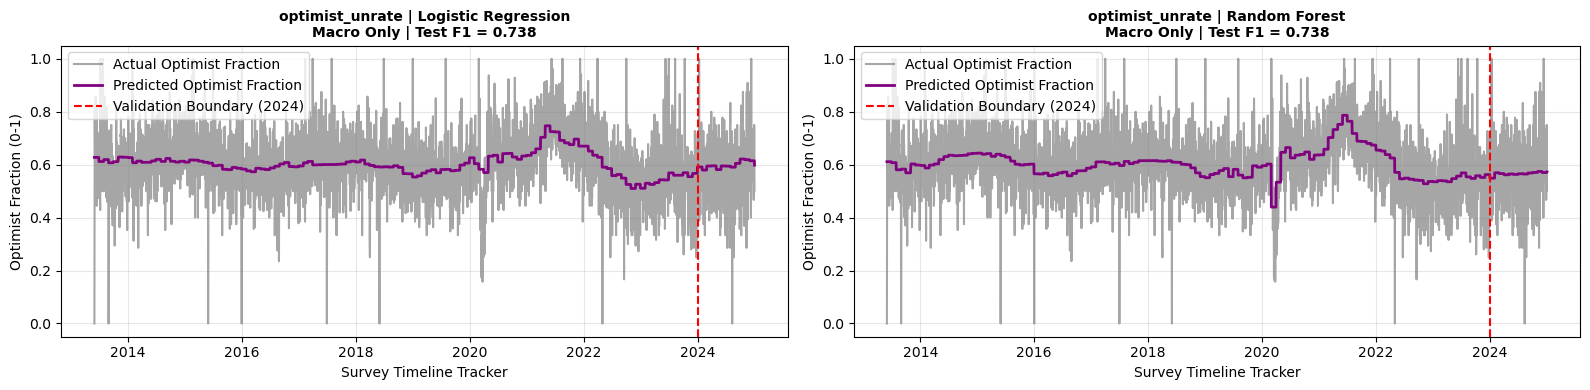


optimist_stocks
Best Logistic: Macro Only | Test F1 = 0.0000
Best Random Forest: Macro + SCE | Test F1 = 0.0114


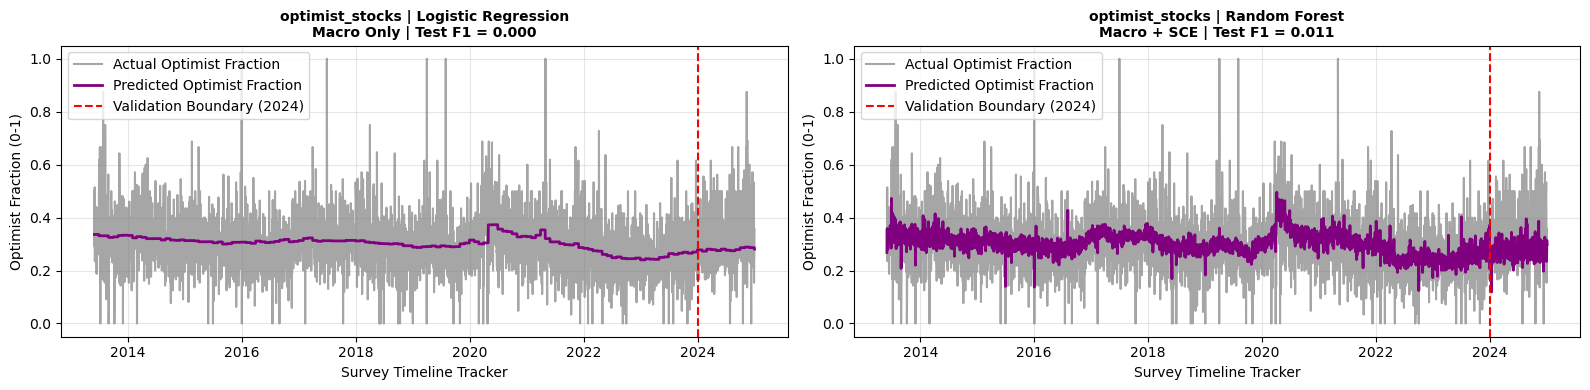


optimist_house_price
Best Logistic: Macro Only | Test F1 = 0.8811
Best Random Forest: Macro Only | Test F1 = 0.8811


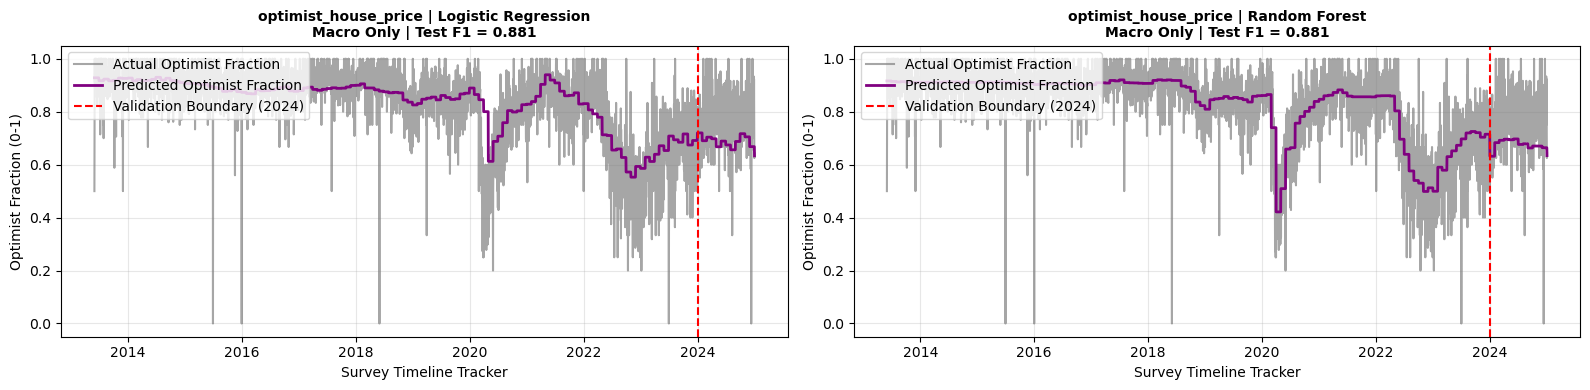

In [28]:
for target in optimist_vars:
    target_models = [m for m in master_results_pt6 if m['Target'] == target]

    best_logit = max(
        [m for m in target_models if m['Classifier'] == 'Logistic Regression'],
        key=lambda x: x['Test F1']
    )

    best_rf = max(
        [m for m in target_models if m['Classifier'] == 'Random Forest'],
        key=lambda x: x['Test F1']
    )

    print(f"\n{target}")
    print(f"Best Logistic: {best_logit['Features']} | Test F1 = {best_logit['Test F1']:.4f}")
    print(f"Best Random Forest: {best_rf['Features']} | Test F1 = {best_rf['Test F1']:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    plot_fractional_forecast(best_logit, ax=axes[0])
    axes[0].set_title(
        f"{target} | Logistic Regression\n{best_logit['Features']} | Test F1 = {best_logit['Test F1']:.3f}",
        fontsize=10,
        fontweight='bold'
    )

    plot_fractional_forecast(best_rf, ax=axes[1])
    axes[1].set_title(
        f"{target} | Random Forest\n{best_rf['Features']} | Test F1 = {best_rf['Test F1']:.3f}",
        fontsize=10,
        fontweight='bold'
    )

    fig.tight_layout()
    plt.show()

### 6.4 Classification Data Master Leaderboard
The table below summarizes the Part 6 classification results across all targets, feature sets, and classifier families. We report the selected hyperparameters together with the main training- and test-sample classification metrics. Higher test F1 indicates better out-of-sample classification performance.

In [29]:
# Map structural matrices onto an automated Pandas display
output_df_cls = pd.DataFrame([
    {k: v for k, v in obj.items() 
     if k not in ['model_pipeline', 'df_eval_used', 'features_used', 'plot_df']}
    for obj in master_results_pt6
])

# Enforce clean column order
output_df_cls = output_df_cls[[
    'Target',
    'Features',
    'Classifier',
    'Opt Parameters',
    'Train F1',
    'Test F1',
    'Test Acc',
    'Test Prec',
    'Test Rec'
]]

output_df_cls = output_df_cls.sort_values(
    by=['Target', 'Test F1'],
    ascending=[True, False]
)

output_df_cls.style.format(precision=4).background_gradient(
    subset=['Test F1'],
    cmap='magma'
)

,Target,Features,Classifier,Opt Parameters,Train F1,Test F1,Test Acc,Test Prec,Test Rec
8,optimist_house_price,Macro Only,Logistic Regression,Opt. C: 0.0001,0.9137,0.8811,0.7875,0.7875,1.0000
9,optimist_house_price,Macro Only,Random Forest,"{'model__max_depth': 5, 'model__n_estimators': 50}",0.9134,0.8811,0.7875,0.7875,1.0000
10,optimist_house_price,Macro + SCE,Logistic Regression,Opt. C: 0.0001,0.9137,0.8811,0.7875,0.7875,1.0000
11,optimist_house_price,Macro + SCE,Random Forest,"{'model__max_depth': 5, 'model__n_estimators': 100}",0.9144,0.8811,0.7875,0.7875,1.0000
7,optimist_stocks,Macro + SCE,Random Forest,"{'model__max_depth': 10, 'model__n_estimators': 50}",0.0392,0.0114,0.6789,0.3889,0.0058
4,optimist_stocks,Macro Only,Logistic Regression,Opt. C: 0.0001,0.0000,0.0000,0.6800,0.0000,0.0000
5,optimist_stocks,Macro Only,Random Forest,"{'model__max_depth': 10, 'model__n_estimators': 50}",0.0000,0.0000,0.6800,0.0000,0.0000
6,optimist_stocks,Macro + SCE,Logistic Regression,Opt. C: 0.0001,0.0023,0.0000,0.6800,0.0000,0.0000
0,optimist_unrate,Macro Only,Logistic Regression,Opt. C: 0.0001,0.7519,0.7382,0.5850,0.5850,1.0000
1,optimist_unrate,Macro Only,Random Forest,"{'model__max_depth': 5, 'model__n_estimators': 50}",0.7515,0.7382,0.5850,0.5850,1.0000


Overall, the classification results show limited differences across model classes for most targets, suggesting that the predictive signal is relatively weak. In several cases, adding individual-level SCE variables does not materially improve out-of-sample performance relative to the macro-only specification. The strongest comparisons should therefore be made using the test-sample F1 scores and the corresponding predicted-fraction plots.

## Part 7 - Conclusion
The following tables summarize the performance of all models estimated in Parts 5 and 6. For the continuous models, we focus on test RMSE and \(R^2\), while for the classification models we focus on test F1 and accuracy.

These tables allow for a direct comparison across model classes and feature sets.

### 7.1 Continuous outcomes (Part 5)

In [30]:
# Output strictly continuous matrix natively devoid of display/HTML plugins
output_df.style.format(precision=4).background_gradient(subset=['Test OOS RMSE'], cmap='viridis_r')

,Target Variable,Feature Depth,Regressive Algorithm,Optimized Alpha,Validation CV MSE,Test OOS RMSE,Test OOS R2
11,house_price_change,Macro + SCE,LassoCV,0.2043,52.2255,7.9255,0.0250
10,house_price_change,Macro + SCE,RidgeCV,4.8939,50.0620,7.9399,0.0214
9,house_price_change,Macro + SCE,LinearRegression,nan,nan,7.9400,0.0214
8,house_price_change,Macro Only,LassoCV,0.2043,53.4279,8.0376,-0.0028
6,house_price_change,Macro Only,LinearRegression,nan,nan,8.0713,-0.0112
7,house_price_change,Macro Only,RidgeCV,4.8939,51.6516,8.0715,-0.0113
3,infl_1y,Macro + SCE,LinearRegression,nan,nan,8.8333,0.0410
4,infl_1y,Macro + SCE,RidgeCV,221.2216,62.8396,8.8350,0.0406
5,infl_1y,Macro + SCE,LassoCV,0.0117,63.0745,8.8907,0.0284
0,infl_1y,Macro Only,LinearRegression,nan,nan,9.0170,0.0006


For the continuous expectation variables, predictive performance is broadly similar across Linear Regression, Ridge, and Lasso models. While Ridge and Lasso introduce regularization and allow for hyperparameter tuning via cross-validation, the resulting improvements in out-of-sample RMSE are generally modest. In several cases, all three models deliver nearly identical performance, suggesting that additional model complexity does not substantially improve predictive performance.

Comparing feature sets, the inclusion of individual-level SCE variables does not lead to consistent or economically meaningful improvements in out-of-sample RMSE. For some targets, the macro + SCE specification performs marginally better, but these gains are small and not systematic, suggesting that most predictive information is already captured by the macro variables.

### 7.2 Binary outcomes (Part 6)

In [31]:
# Output strictly categorical probability matrix via native Jupyter cell bounding
output_df_cls.style.format(precision=4).background_gradient(subset=['Test F1'], cmap='magma')

,Target,Features,Classifier,Opt Parameters,Train F1,Test F1,Test Acc,Test Prec,Test Rec
8,optimist_house_price,Macro Only,Logistic Regression,Opt. C: 0.0001,0.9137,0.8811,0.7875,0.7875,1.0000
9,optimist_house_price,Macro Only,Random Forest,"{'model__max_depth': 5, 'model__n_estimators': 50}",0.9134,0.8811,0.7875,0.7875,1.0000
10,optimist_house_price,Macro + SCE,Logistic Regression,Opt. C: 0.0001,0.9137,0.8811,0.7875,0.7875,1.0000
11,optimist_house_price,Macro + SCE,Random Forest,"{'model__max_depth': 5, 'model__n_estimators': 100}",0.9144,0.8811,0.7875,0.7875,1.0000
7,optimist_stocks,Macro + SCE,Random Forest,"{'model__max_depth': 10, 'model__n_estimators': 50}",0.0392,0.0114,0.6789,0.3889,0.0058
4,optimist_stocks,Macro Only,Logistic Regression,Opt. C: 0.0001,0.0000,0.0000,0.6800,0.0000,0.0000
5,optimist_stocks,Macro Only,Random Forest,"{'model__max_depth': 10, 'model__n_estimators': 50}",0.0000,0.0000,0.6800,0.0000,0.0000
6,optimist_stocks,Macro + SCE,Logistic Regression,Opt. C: 0.0001,0.0023,0.0000,0.6800,0.0000,0.0000
0,optimist_unrate,Macro Only,Logistic Regression,Opt. C: 0.0001,0.7519,0.7382,0.5850,0.5850,1.0000
1,optimist_unrate,Macro Only,Random Forest,"{'model__max_depth': 5, 'model__n_estimators': 50}",0.7515,0.7382,0.5850,0.5850,1.0000


For the binary optimism variables, Logistic Regression and Random Forest models produce very similar results. For `optimist_unrate` and `optimist_house_price`, both classifiers achieve nearly identical F1 scores across specifications, indicating limited gains from increased model complexity.

For `optimist_stocks`, performance is substantially weaker, with very low F1 scores across all models. This suggests that the models struggle to identify the positive class, likely reflecting class imbalance and/or a weak predictive signal. Despite moderate accuracy, the low F1 scores indicate poor classification of optimistic outcomes.

As in the continuous setting, adding SCE variables does not lead to meaningful or consistent improvements in performance. In some cases, the macro-only specification performs just as well as—or slightly better than—the expanded feature set.

### 7.3 Overall conclusions
Across both continuous and binary prediction tasks, the results suggest that:

- Model choice (Linear vs. Ridge/Lasso vs. Random Forest) has limited impact on out-of-sample performance.
- The predictive signal in the available covariates is relatively weak.
- Additional individual-level SCE variables do not systematically improve predictive accuracy.
- Simpler models often perform comparably to more complex alternatives.

Overall, these findings highlight the difficulty of forecasting expectations using the available data. While machine learning methods provide a structured framework for estimation and validation, their performance is constrained by the limited informational content of the features.